In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy import stats
from tqdm.notebook import tqdm

/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
ASKING_ROOT = Path('../../data/statscan-quarterly-rental-clean/can-cma-all')
CMHC_ROOT   = Path('../../data/cmhc-rental-clean/can-cma-primary/primary-summary')
REF_ROOT    = Path('../../data/reference')
REF_ROOT.mkdir(parents=True, exist_ok=True)

BED_TYPE = 'Apt 2br'   # default unit type for the StatCan asking-rent series

# ── CPI, all-items Canada, 2002=100 (Statistics Canada) ──────────────────
CPI_YEARS  = list(range(1990, 2026))
CPI_VALUES = [
    78.4,  82.8,  84.0,  85.6,  85.7,  87.6,  88.9,  90.4,  91.3,  92.9,
    95.4,  97.8, 100.0, 102.8, 104.7, 107.0, 109.1, 111.5, 114.1, 114.4,
   116.5, 119.9, 121.7, 122.8, 125.2, 126.6, 128.4, 130.4, 133.4, 136.0,
   137.0, 141.6, 151.2, 157.1, 160.9, 164.2,
]
CPI_CANADA = pd.Series(CPI_VALUES, index=CPI_YEARS, name='CPI')

# ── Median total income, economic families & persons not in an economic
# family, 2024 constant dollars (Statistics Canada). No 2025 data yet.
INCOME_YEARS = list(range(1990, 2025))
INCOME_CANADA_VALUES = [
    71_800, 67_800, 67_600, 66_000, 66_600, 66_600, 65_500, 65_300, 67_300, 69_300,
    70_300, 71_900, 71_500, 71_400, 72_400, 73_400, 75_200, 76_600, 77_600, 76_200,
    75_800, 75_700, 77_900, 78_400, 80_900, 80_400, 79_500, 81_900, 82_200, 81_900,
    87_300, 87_600, 84_400, 85_500, 86_000,
]
INCOME_CANADA = pd.Series(INCOME_CANADA_VALUES, index=INCOME_YEARS, name='Median_Income')

# CMHC file name -> StatCan file name, where the two datasets spell the
# same CMA differently.
CMHC_TO_STATCAN_NAME = {
    'quebec city': 'quebec',
    "st john's":   "st. john's",
}

# A city is "meaningfully" below peak once it has fallen more than this much —
# distinguishes real softening from quarter-to-quarter noise.
MATERIAL_DECLINE_PCT = -2.0

# ── Chart style (reference palette, consistent with other notebooks) ────
C1 = '#2a78d6'  # blue   — headline / nominal series
C2 = '#1baf7a'  # aqua   — real / CPI-adjusted series
C3 = '#eda100'  # yellow — secondary comparator
C4 = '#008300'  # green  — decline / below-peak
C5 = '#4a3aa7'  # violet — income / affordability
C6 = '#e34948'  # red    — rise / at-or-above peak

SURFACE  = '#fcfcfb'
INK      = '#0b0b0b'
INK2     = '#52514e'
MUTED    = '#898781'
GRID_CLR = '#e1e0d9'

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.edgecolor':    GRID_CLR,
    'axes.labelcolor':   INK2,
    'xtick.color':       INK2,
    'ytick.color':       INK2,
    'grid.color':        GRID_CLR,
    'grid.linewidth':    0.5,
    'figure.facecolor':  SURFACE,
    'axes.facecolor':    SURFACE,
})

# Have Rents Actually Fallen?

The media narrative in the last year has been that Canadian rents are falling.
This notebook checks that claim against the data for major Census Metropolitan
Areas (CMAs), using two complementary sources:

- **StatCan asking rents** (quarterly, Q1 2019 – Q1 2026) — rents advertised for
  new listings, a leading indicator of where the market is heading. Short
  history, but timely. We use the **2-bedroom apartment** series throughout.
- **CMHC primary market average rent** (annual, back to 1990 for most CMAs) —
  the average rent paid across the *entire* rental stock (all bedroom types
  combined; a CMA-level 2-bedroom breakout isn't available in this dataset).
  Longer history, but slower-moving and less current.

The working hypothesis: where rents have fallen, the drop is **modest relative
to the run-up that preceded it**, and it is **far from universal** across
cities. We test that with each city's own peak as the benchmark, in both
nominal and inflation-adjusted terms, and check whether the two datasets tell
the same story.

## Section 1 — Reference Data

Persist Canada-wide CPI and median income to `data/reference/` (companions to
the existing Ontario-only files) so other notebooks can reuse them without
re-entering the raw values. CPI is annual all-items, 2002 = 100. Income is
median total income for economic families and persons not in an economic
family, in 2024 constant dollars — StatCan has not yet published 2025 figures.

In [3]:
CPI_CANADA.rename_axis('Year').reset_index().to_csv(
    REF_ROOT / 'cpi_canada.csv', index=False)
INCOME_CANADA.rename_axis('Year').reset_index().to_csv(
    REF_ROOT / 'income_canada.csv', index=False)

for f in ['cpi_canada.csv', 'income_canada.csv']:
    print(f)

cpi_canada.csv
income_canada.csv


## Section 2 — Load Asking Rents (StatCan, Quarterly)

One series per CMA, plus StatCan's own **"All CMAs"** national aggregate
(`all.csv`) — that file is StatCan's pre-built national roll-up from the same
source table, not something derived here.

In [4]:
def parse_quarter(label: str) -> pd.Period:
    q, y = label.split()
    return pd.Period(f'{y}{q}', freq='Q')


def load_asking(fp: Path) -> pd.Series:
    df = pd.read_csv(fp)
    df['period'] = df['Quarter'].map(parse_quarter)
    return df.set_index('period')[BED_TYPE].sort_index().dropna().rename(fp.stem)


asking_files = sorted(p for p in ASKING_ROOT.glob('*.csv') if p.stem != 'all')
asking = {p.stem: s for p in tqdm(asking_files, desc='asking rents')
          if len(s := load_asking(p)) >= 8}
asking_national = load_asking(ASKING_ROOT / 'all.csv')

skipped = [p.stem for p in asking_files if p.stem not in asking]
print(f'{len(asking)} CMAs loaded ({len(skipped)} skipped for too little 2BR data: {skipped})')
print(f'National series: {asking_national.index.min()} - {asking_national.index.max()}')

asking rents:   0%|          | 0/42 [00:00<?, ?it/s]

40 CMAs loaded (2 skipped for too little 2BR data: ['saguenay', 'trois-rivieres'])
National series: 2019Q1 - 2026Q1


## Section 3 — Load CMHC Average Rent (Annual, Primary Market)

CMHC has no pre-built national aggregate at the CMA level (unlike StatCan's
asking-rent table), and there's no established methodology in this project for
building one — so we don't invent a single "Canada" number here. Instead
Section 7 summarizes the cross-city distribution directly.

Cities with fewer than 5 years of data (e.g. Windsor, St. Catharines–Niagara —
both recent CMHC additions) are dropped; there isn't enough history to talk
about "peak."

In [5]:
def load_cmhc(fp: Path) -> pd.DataFrame:
    return pd.read_csv(fp).set_index('Year').sort_index()


cmhc_files = sorted(CMHC_ROOT.glob('*.csv'))
cmhc = {}
for fp in tqdm(cmhc_files, desc='CMHC primary market'):
    name = CMHC_TO_STATCAN_NAME.get(fp.stem, fp.stem)
    df = load_cmhc(fp)
    if df['Average Rent'].notna().sum() < 5:
        continue
    cmhc[name] = df

print(f'{len(cmhc)} CMAs with usable CMHC history (of {len(cmhc_files)} files)')

CMHC primary market:   0%|          | 0/42 [00:00<?, ?it/s]

40 CMAs with usable CMHC history (of 42 files)


## Section 4 — Deflating to Real Dollars

CPI is annual, so every quarter in a given year is deflated by that year's CPI
— a standard approximation given no quarterly CPI series was supplied. Both
series are rescaled into **constant dollars of the last CPI year available
(2025)**; the StatCan data's Q1 2026 observation uses the 2025 CPI as a
placeholder since 2026 CPI isn't published yet.

In [6]:
def deflate_quarterly(series: pd.Series, cpi: pd.Series) -> pd.Series:
    base_year = cpi.index.max()
    years = series.index.map(lambda p: p.year)
    cpi_vals = cpi.reindex(years).ffill()
    cpi_vals.index = series.index
    return series * (cpi[base_year] / cpi_vals)


def deflate_annual(series: pd.Series, cpi: pd.Series) -> pd.Series:
    base_year = cpi.index.max()
    cpi_vals = cpi.reindex(series.index).ffill()
    return series * (cpi[base_year] / cpi_vals)


print(f'Deflating to constant {CPI_CANADA.index.max()} dollars.')

Deflating to constant 2025 dollars.


## Section 5 — Peak vs. Latest, City by City

For every city and both datasets: find the highest value the series has ever
reached, compare it to the latest observation, and express the gap as a %
change — once in nominal dollars, once in real (inflation-adjusted) dollars.
A city sitting at 0% is still at its all-time high; only negative values
represent an actual fall from peak.

In [7]:
def peak_stats(series: pd.Series) -> dict:
    peak_p, latest_p = series.idxmax(), series.index.max()
    peak_v, latest_v = series[peak_p], series[latest_p]
    return dict(peak_period=peak_p, peak_value=peak_v,
                latest_period=latest_p, latest_value=latest_v,
                pct_change=(latest_v - peak_v) / peak_v * 100)


asking_rows = []
for city, series in asking.items():
    real = deflate_quarterly(series, CPI_CANADA)
    nom, rl = peak_stats(series), peak_stats(real)
    asking_rows.append({
        'city': city,
        'peak_q_nom': nom['peak_period'], 'peak_$_nom': nom['peak_value'],
        'latest_$_nom': nom['latest_value'], 'pct_nom': nom['pct_change'],
        'peak_q_real': rl['peak_period'], 'peak_$_real': rl['peak_value'],
        'latest_$_real': rl['latest_value'], 'pct_real': rl['pct_change'],
        'quarters_since_peak': series.index.max().ordinal - nom['peak_period'].ordinal,
    })
asking_peak = pd.DataFrame(asking_rows).set_index('city').sort_values('pct_nom')

national_nom  = peak_stats(asking_national)
national_real = peak_stats(deflate_quarterly(asking_national, CPI_CANADA))
run_up_pct = (national_nom['peak_value'] - asking_national.iloc[0]) / asking_national.iloc[0] * 100

print('National (All CMAs) — 2BR asking rent')
print(f'  Run-up:  {asking_national.index[0]} \${asking_national.iloc[0]:.0f}  ->  '
      f'peak {national_nom["peak_period"]} \${national_nom["peak_value"]:.0f}  ({run_up_pct:+.1f}%)')
print(f'  Nominal: peak {national_nom["peak_period"]} \${national_nom["peak_value"]:.0f}  ->  '
      f'latest {national_nom["latest_period"]} \${national_nom["latest_value"]:.0f}  '
      f'({national_nom["pct_change"]:+.1f}%)')
print(f'  Real:    peak {national_real["peak_period"]} \${national_real["peak_value"]:.0f}  ->  '
      f'latest {national_real["latest_period"]} \${national_real["latest_value"]:.0f}  '
      f'({national_real["pct_change"]:+.1f}%)')
print(f'  The correction so far is {abs(national_nom["pct_change"]) / run_up_pct * 100:.0f}% of the size of the run-up (nominal terms).')
print()
asking_peak.round(1)

National (All CMAs) — 2BR asking rent
  Run-up:  2019Q1 \$1520  ->  peak 2023Q4 \$2250  (+48.0%)
  Nominal: peak 2023Q4 \$2250  ->  latest 2026Q1 \$2150  (-4.4%)
  Real:    peak 2023Q4 \$2352  ->  latest 2026Q1 \$2150  (-8.6%)
  The correction so far is 9% of the size of the run-up (nominal terms).



,peak_q_nom,peak_$_nom,latest_$_nom,pct_nom,peak_q_real,peak_$_real,latest_$_real,pct_real,quarters_since_peak
city,,,,,,,,,
kelowna,2022Q3,2720.0,2320.0,-14.7,2022Q3,2953.9,2320.0,-21.5,14
vancouver,2023Q3,3580.0,3100.0,-13.4,2023Q3,3741.8,3100.0,-17.2,10
calgary,2024Q2,2150.0,1900.0,-11.6,2023Q4,2226.3,1900.0,-14.7,7
abbotsford-mission,2024Q3,2130.0,1920.0,-9.9,2024Q3,2173.7,1920.0,-11.7,6
st. john's,2024Q4,1740.0,1570.0,-9.8,2024Q4,1775.7,1570.0,-11.6,5
quebec,2024Q3,1570.0,1430.0,-8.9,2024Q3,1602.2,1430.0,-10.7,6
toronto,2023Q3,2920.0,2660.0,-8.9,2019Q1,3090.8,2660.0,-13.9,10
kitchener-cambridge-waterloo,2023Q4,2300.0,2110.0,-8.3,2023Q4,2403.9,2110.0,-12.2,9
chilliwack,2024Q1,1840.0,1690.0,-8.2,2021Q3,1948.1,1690.0,-13.3,8


In [8]:
cmhc_rows = []
for city, df in cmhc.items():
    series = df['Average Rent'].dropna()
    real = deflate_annual(series, CPI_CANADA)
    nom, rl = peak_stats(series), peak_stats(real)
    cmhc_rows.append({
        'city': city,
        'peak_yr_nom': nom['peak_period'], 'peak_$_nom': nom['peak_value'],
        'latest_$_nom': nom['latest_value'], 'pct_nom': nom['pct_change'],
        'peak_yr_real': rl['peak_period'], 'peak_$_real': rl['peak_value'],
        'latest_$_real': rl['latest_value'], 'pct_real': rl['pct_change'],
        'years_since_peak': series.index.max() - nom['peak_period'],
    })
cmhc_peak = pd.DataFrame(cmhc_rows).set_index('city').sort_values('pct_nom')

n_at_peak = int((cmhc_peak['pct_nom'] == 0).sum())
print(f'{n_at_peak}/{len(cmhc_peak)} CMAs have their all-time-high CMHC average rent '
      f'in the latest available year ({cmhc_peak["peak_yr_nom"].max()}) — i.e. by this '
      f'slower, whole-market measure, {"none" if n_at_peak == len(cmhc_peak) else f"only {len(cmhc_peak) - n_at_peak}"} '
      f'of these cities has actually fallen from its own historical peak yet.')
print()
cmhc_peak.round(1)

40/40 CMAs have their all-time-high CMHC average rent in the latest available year (2025) — i.e. by this slower, whole-market measure, none of these cities has actually fallen from its own historical peak yet.



,peak_yr_nom,peak_$_nom,latest_$_nom,pct_nom,peak_yr_real,peak_$_real,latest_$_real,pct_real,years_since_peak
city,,,,,,,,,
abbotsford-mission,2025,1447.0,1447.0,0.0,2025,1447.0,1447.0,0.0,0
barrie,2025,1697.0,1697.0,0.0,2025,1697.0,1697.0,0.0,0
belleville-quinte west,2025,1447.0,1447.0,0.0,2025,1447.0,1447.0,0.0,0
brantford,2025,1549.0,1549.0,0.0,2025,1549.0,1549.0,0.0,0
calgary,2025,1775.0,1775.0,0.0,2024,1779.8,1775.0,-0.3,0
chilliwack,2025,1386.0,1386.0,0.0,2025,1386.0,1386.0,0.0,0
drummondville,2025,1085.0,1085.0,0.0,2025,1085.0,1085.0,0.0,0
edmonton,2025,1493.0,1493.0,0.0,2015,1507.1,1493.0,-0.9,0
fredericton,2025,1427.0,1427.0,0.0,2025,1427.0,1427.0,0.0,0


## Section 6 — The National Trajectory

Nominal vs. real (constant-dollar) national 2-bedroom asking rent, with each
series' own peak marked.

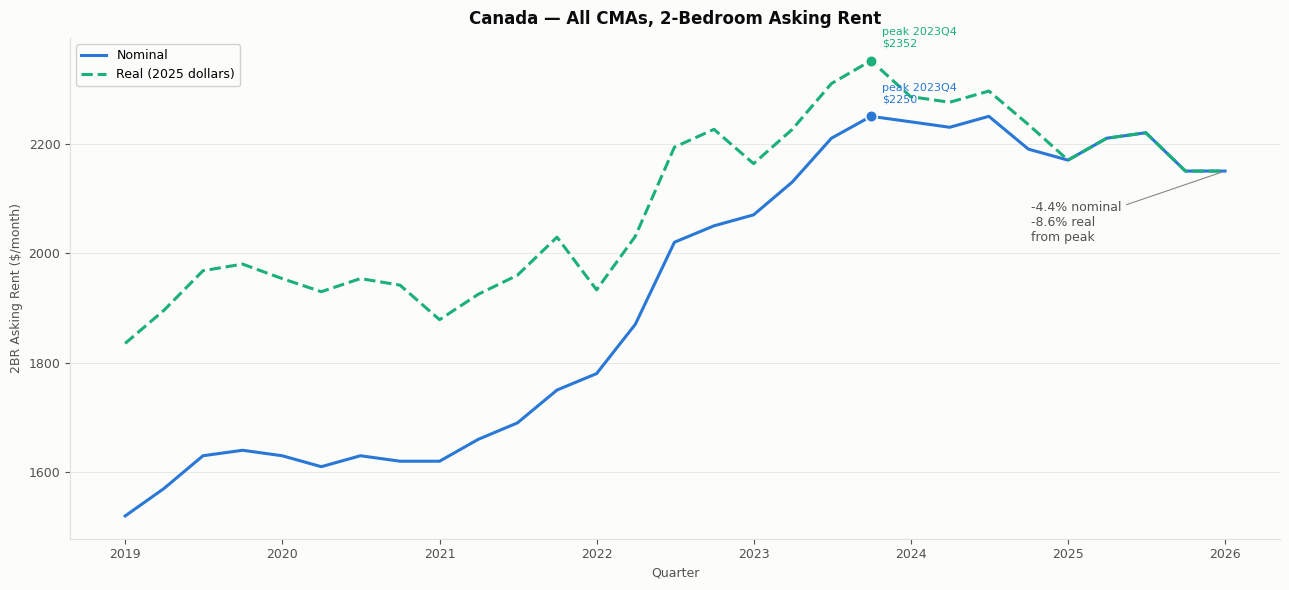

In [9]:
real_national = deflate_quarterly(asking_national, CPI_CANADA)
x = asking_national.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(x, asking_national.values, color=C1, linewidth=2.2, label='Nominal')
ax.plot(x, real_national.values, color=C2, linewidth=2.2, linestyle='--',
        label=f'Real ({CPI_CANADA.index.max()} dollars)')

for stats_d, color in [(national_nom, C1), (national_real, C2)]:
    px = stats_d['peak_period'].to_timestamp()
    ax.scatter([px], [stats_d['peak_value']], color=color, s=70, zorder=6,
               edgecolors=SURFACE, linewidths=1.2)
    ax.annotate(f'peak {stats_d["peak_period"]}\n\${stats_d["peak_value"]:.0f}',
                (px, stats_d['peak_value']), xytext=(8, 10),
                textcoords='offset points', fontsize=8, color=color)

lx = asking_national.index.max().to_timestamp()
ax.annotate(f'{national_nom["pct_change"]:+.1f}% nominal\n{national_real["pct_change"]:+.1f}% real\nfrom peak',
            (lx, asking_national.values[-1]), xytext=(-140, -50),
            textcoords='offset points', fontsize=9, color=INK2,
            arrowprops=dict(arrowstyle='-', color=MUTED, linewidth=0.8))

ax.set_ylabel('2BR Asking Rent ($/month)', fontsize=9)
ax.set_xlabel('Quarter', fontsize=9)
ax.set_title('Canada — All CMAs, 2-Bedroom Asking Rent', fontsize=12,
             fontweight='bold', color=INK, pad=10)
ax.legend(loc='upper left', fontsize=9, framealpha=0.88)
ax.grid(axis='y')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

## Section 7 — Testing the Hypothesis, City by City

The working hypothesis has four separate, testable parts. Treating each CMA
as one paired observation (peak vs. latest), we test each in turn:

1. **Is a fall from peak real and widespread**, or a coincidence in a handful
   of cities? (one-sample t-test + Wilcoxon signed-rank on % change from
   peak; sign tests on how many cities are below peak at all / materially so)
2. **Is the fall modest relative to the run-up that preceded it?** — the
   central "modest" claim, tested directly by comparing each city's own
   2019→peak run-up against its peak→latest correction, plus a one-sided
   test against a fixed "meaningful reversal" benchmark
3. **Does inflation change the picture?** — are real (constant-dollar)
   declines systematically larger than nominal ones (paired Wilcoxon on the
   real-vs-nominal gap)
4. **Is this a recent, common turning point, or a long-scattered one?** — do
   individual cities' peaks cluster tightly in time, or are they spread
   evenly across the whole 2019–2026 window (chi-square goodness-of-fit)
5. **Do the two independent data sources agree on *which* cities are below
   peak?** — a paired (McNemar) test on incidence, since StatCan asking rents
   and CMHC average rent are two lenses on the same 38 cities, not
   independent samples
6. Given source disagreement on incidence, **is there still a graded,
   directional relationship** between the size of a city's asking-rent
   correction and how much its CMHC average-rent growth has slowed?

In [10]:
# ── Test 1: is the fall real and widespread? ──────────────────────────────
n = len(asking_peak)
t_stat, t_p = stats.ttest_1samp(asking_peak['pct_nom'], 0)
w_stat, w_p = stats.wilcoxon(asking_peak['pct_nom'])

n_below    = int((asking_peak['pct_nom'] < 0).sum())
n_material = int((asking_peak['pct_nom'] < MATERIAL_DECLINE_PCT).sum())
binom_below    = stats.binomtest(n_below, n, 0.5, alternative='greater')
binom_material = stats.binomtest(n_material, n, 0.5, alternative='greater')

print(f'Test 1 — Asking rents (StatCan, 2BR), {n} CMAs, peak vs. latest quarter (nominal)')
print('-' * 68)
print(f'  Mean pct change from peak:   {asking_peak["pct_nom"].mean():+.2f}%')
print(f'  Median pct change from peak: {asking_peak["pct_nom"].median():+.2f}%')
print(f'  One-sample t-test (H0: mean = 0):        t = {t_stat:+.3f}  p = {t_p:.4f}')
print(f'  Wilcoxon signed-rank (H0: median = 0):    W = {w_stat:.1f}  p = {w_p:.4f}')
print()
print(f'  Cities below peak at all:      {n_below}/{n}  ({100*n_below/n:.0f}%)   '
      f'sign test p = {binom_below.pvalue:.4f}')
print(f'  Cities materially below peak (< {MATERIAL_DECLINE_PCT:.0f}%): '
      f'{n_material}/{n}  ({100*n_material/n:.0f}%)   sign test p = {binom_material.pvalue:.4f}')
print()
print('  Verdict: the fall is both statistically significant and widespread —')
print('  this is not a handful of cities driving the headline.')

Test 1 — Asking rents (StatCan, 2BR), 40 CMAs, peak vs. latest quarter (nominal)
--------------------------------------------------------------------
  Mean pct change from peak:   -4.93%
  Median pct change from peak: -4.55%
  One-sample t-test (H0: mean = 0):        t = -8.346  p = 0.0000
  Wilcoxon signed-rank (H0: median = 0):    W = 0.0  p = 0.0000

  Cities below peak at all:      35/40  (88%)   sign test p = 0.0000
  Cities materially below peak (< -2%): 30/40  (75%)   sign test p = 0.0011

  Verdict: the fall is both statistically significant and widespread —
  this is not a handful of cities driving the headline.


In [11]:
# ── Test 2: is the fall modest relative to the run-up? ────────────────────
run_up = pd.Series({
    city: (asking_peak.loc[city, 'peak_$_nom'] - asking[city].iloc[0]) / asking[city].iloc[0] * 100
    for city in asking_peak.index
})
correction_mag = asking_peak['pct_nom'].abs()
ratio_pct = correction_mag / run_up * 100

t_ru, p_ru = stats.ttest_rel(run_up, correction_mag)
w_ru, pw_ru = stats.wilcoxon(run_up, correction_mag)

t10, p10 = stats.ttest_1samp(asking_peak['pct_nom'], -10, alternative='greater')
t10_r, p10_r = stats.ttest_1samp(asking_peak['pct_real'], -10, alternative='greater')

print(f'Test 2 — Correction size vs. the run-up that preceded it, {n} CMAs')
print('-' * 68)
print(f'  Mean run-up (own first quarter -> own peak):   {run_up.mean():+.1f}%')
print(f'  Mean correction (peak -> latest, nominal):      {-correction_mag.mean():+.1f}%')
print(f'  Median correction as a share of the run-up:      {ratio_pct.median():.1f}%')
print(f'  Paired t-test (H0: run-up == correction magnitude):   t = {t_ru:+.3f}  p = {p_ru:.4g}')
print(f'  Wilcoxon signed-rank (same H0):                       W = {w_ru:.1f}  p = {pw_ru:.4g}')
print()
print('  One-sided test against a fixed "meaningful reversal" benchmark of -10%:')
print(f'    Nominal (H0: median <= -10%, H1: median > -10%):  t = {t10:+.3f}  p = {p10:.4f}')
print(f'    Real    (H0: median <= -10%, H1: median > -10%):  t = {t10_r:+.3f}  p = {p10_r:.4f}')
print()
print('  Verdict: the correction is a small fraction of the preceding run-up, and is')
print('  significantly shallower than a 10% reversal even in real terms — "modest" holds')
print('  up as a quantitative claim, not just a qualitative impression.')

Test 2 — Correction size vs. the run-up that preceded it, 40 CMAs
--------------------------------------------------------------------
  Mean run-up (own first quarter -> own peak):   +59.1%
  Mean correction (peak -> latest, nominal):      -4.9%
  Median correction as a share of the run-up:      8.4%
  Paired t-test (H0: run-up == correction magnitude):   t = +18.073  p = 1.49e-20
  Wilcoxon signed-rank (same H0):                       W = 0.0  p = 1.819e-12

  One-sided test against a fixed "meaningful reversal" benchmark of -10%:
    Nominal (H0: median <= -10%, H1: median > -10%):  t = +8.567  p = 0.0000
    Real    (H0: median <= -10%, H1: median > -10%):  t = +3.526  p = 0.0005

  Verdict: the correction is a small fraction of the preceding run-up, and is
  significantly shallower than a 10% reversal even in real terms — "modest" holds
  up as a quantitative claim, not just a qualitative impression.


In [12]:
# ── Test 3: does inflation change the picture? ────────────────────────────
gap = asking_peak['pct_real'] - asking_peak['pct_nom']
tg_stat, tg_p = stats.ttest_1samp(gap, 0)
wg_stat, wg_p = stats.wilcoxon(gap)

print('Test 3 — Real vs. nominal decline from peak (paired by city)')
print('-' * 68)
print(f'  Mean real pct change:    {asking_peak["pct_real"].mean():+.2f}%')
print(f'  Mean nominal pct change: {asking_peak["pct_nom"].mean():+.2f}%')
print(f'  Mean gap (real - nominal): {gap.mean():+.2f} pp')
print(f'  Paired t-test (H0: gap = 0):       t = {tg_stat:+.3f}  p = {tg_p:.4f}')
print(f'  Wilcoxon signed-rank (H0: gap = 0): W = {wg_stat:.1f}  p = {wg_p:.4f}')
print()
if gap.mean() < 0:
    print('  Real declines are larger than nominal declines. This is favourable, not')
    print('  unfavourable, for the "how much relief since peak" question: CPI kept rising')
    print('  after the peak, so a peak-era dollar is worth more than a latest-quarter')
    print('  dollar. Re-stated in constant dollars, the peak itself was even higher than')
    print('  its sticker price — so the drop since then is *larger* than the nominal')
    print('  number suggests, not smaller. It says nothing about affordability in the')
    print('  wage sense (see Section 11) — only that rent has cooled by more than face')
    print('  value once general inflation over the same window is stripped out.')
else:
    print('  Nominal declines are larger than real declines: disinflation means the peak')
    print('  itself looks smaller once re-stated in constant dollars, so the drop since')
    print('  then is *smaller* in real terms than the nominal number suggests — less')
    print('  relief than face value implies.')

Test 3 — Real vs. nominal decline from peak (paired by city)
--------------------------------------------------------------------
  Mean real pct change:    -7.26%
  Mean nominal pct change: -4.93%
  Mean gap (real - nominal): -2.33 pp
  Paired t-test (H0: gap = 0):       t = -8.804  p = 0.0000
  Wilcoxon signed-rank (H0: gap = 0): W = 0.0  p = 0.0000

  Real declines are larger than nominal declines. This is favourable, not
  unfavourable, for the "how much relief since peak" question: CPI kept rising
  after the peak, so a peak-era dollar is worth more than a latest-quarter
  dollar. Re-stated in constant dollars, the peak itself was even higher than
  its sticker price — so the drop since then is *larger* than the nominal
  number suggests, not smaller. It says nothing about affordability in the
  wage sense (see Section 11) — only that rent has cooled by more than face
  value once general inflation over the same window is stripped out.


In [13]:
# ── Test 4: are peaks clustered in time, or scattered? ────────────────────
peak_years = asking_peak['peak_q_nom'].map(lambda p: p.year)
year_range = range(2019, 2027)
observed = peak_years.value_counts().reindex(year_range, fill_value=0).sort_index()
expected = np.full(len(observed), observed.sum() / len(observed))

chi2_stat, chi2_p = stats.chisquare(observed.values, expected)

print(f'Test 4 — When did each city peak? ({n} CMAs)')
print('-' * 68)
print(observed.rename('n_cities_peaking').to_string())
print()
print(f'Chi-square goodness-of-fit vs. uniform across {len(observed)} years: '
      f'chi2 = {chi2_stat:.2f}  p = {chi2_p:.4g}')
print()
qsp = asking_peak['quarters_since_peak']
n_recent = int((peak_years >= 2024).sum())
print(f'  Quarters since peak (as of the latest available quarter): '
      f'median = {qsp.median():.0f}, mean = {qsp.mean():.1f}, max = {qsp.max():.0f}')
print(f'  {n_recent}/{n} CMAs ({100*n_recent/n:.0f}%) peaked in 2024 or later.')
print()
print('  Verdict: peaks are heavily concentrated in 2023-2025 rather than scattered')
print('  evenly across the seven-year window — there really is a common, recent turning')
print('  point behind the headlines, even though its size (Test 2) is modest.')

Test 4 — When did each city peak? (40 CMAs)
--------------------------------------------------------------------
peak_q_nom
2019     0
2020     0
2021     0
2022     1
2023     8
2024    19
2025     9
2026     3

Chi-square goodness-of-fit vs. uniform across 8 years: chi2 = 63.20  p = 3.456e-11

  Quarters since peak (as of the latest available quarter): median = 6, mean = 5.8, max = 14
  31/40 CMAs (78%) peaked in 2024 or later.

  Verdict: peaks are heavily concentrated in 2023-2025 rather than scattered
  evenly across the seven-year window — there really is a common, recent turning
  point behind the headlines, even though its size (Test 2) is modest.


In [14]:
# ── Test 5: do the two sources agree on WHICH cities are below peak? ──────
# This is a paired comparison (both sources cover the same cities), so a
# McNemar test on the discordant pairs is the right tool — not an
# independent-samples test like Fisher's exact or a two-proportion z-test.
common_cities = sorted(set(asking_peak.index) & set(cmhc_peak.index))
asking_below = asking_peak.loc[common_cities, 'pct_nom'] < 0
cmhc_below   = cmhc_peak.loc[common_cities, 'pct_nom'] < 0

a = int((asking_below & cmhc_below).sum())
b = int((asking_below & ~cmhc_below).sum())
c = int((~asking_below & cmhc_below).sum())
d = int((~asking_below & ~cmhc_below).sum())
discordant = b + c

print(f'Test 5 — Cross-source agreement on incidence, {len(common_cities)} common CMAs (paired)')
print('-' * 68)
print('                          CMHC: below peak   CMHC: at/above peak')
print(f'  Asking: below peak            {a:>3}                  {b:>3}')
print(f'  Asking: at/above peak         {c:>3}                  {d:>3}')
print()
print(f'  Asking rents: {int(asking_below.sum())}/{len(common_cities)} '
      f'({100*asking_below.mean():.0f}%) of CMAs below peak')
print(f'  CMHC:         {int(cmhc_below.sum())}/{len(common_cities)} '
      f'({100*cmhc_below.mean():.0f}%) of CMAs below peak')
if discordant:
    mcnemar = stats.binomtest(min(b, c), discordant, 0.5, alternative='two-sided')
    print(f'  McNemar exact test on the {discordant} discordant pairs: p = {mcnemar.pvalue:.4g}')
print()
print('  Verdict: the two sources sharply disagree on incidence. The fast-moving')
print('  asking-rent series records most major CMAs below their own peak, while CMHC')
print('  average rent has (essentially) never recorded one below its own historical')
print('  high. The softening is real in the leading indicator and has not yet reached')
print('  the broader rent actually paid.')

Test 5 — Cross-source agreement on incidence, 38 common CMAs (paired)
--------------------------------------------------------------------
                          CMHC: below peak   CMHC: at/above peak
  Asking: below peak              0                   33
  Asking: at/above peak           0                    5

  Asking rents: 33/38 (87%) of CMAs below peak
  CMHC:         0/38 (0%) of CMAs below peak
  McNemar exact test on the 33 discordant pairs: p = 2.328e-10

  Verdict: the two sources sharply disagree on incidence. The fast-moving
  asking-rent series records most major CMAs below their own peak, while CMHC
  average rent has (essentially) never recorded one below its own historical
  high. The softening is real in the leading indicator and has not yet reached
  the broader rent actually paid.


In [15]:
# ── Test 6: given that disagreement, is there still a graded signal? ──────
# cmhc_peak['pct_nom'] is 0.0 for effectively every CMA (Test 5), so there's
# nothing to correlate against there directly. Instead: do cities with the
# sharpest asking-rent corrections at least show the *slowest* CMHC
# average-rent growth in the latest year available?
cmhc_latest_yoy = {}
for city, df in cmhc.items():
    series = df['Average Rent'].dropna()
    yoy = series.pct_change().dropna() * 100
    if len(yoy):
        cmhc_latest_yoy[city] = yoy.iloc[-1]

corr_cities = sorted(set(asking_peak.index) & set(cmhc_latest_yoy))
paired = pd.DataFrame({
    'asking_pct_from_peak': asking_peak.loc[corr_cities, 'pct_nom'],
    'cmhc_latest_yoy_pct':  pd.Series(cmhc_latest_yoy).loc[corr_cities],
})

r_s, p_s = stats.spearmanr(paired['asking_pct_from_peak'], paired['cmhc_latest_yoy_pct'])
r_p, p_p = stats.pearsonr(paired['asking_pct_from_peak'], paired['cmhc_latest_yoy_pct'])

print(f'Test 6 — Graded cross-source signal, {len(paired)} CMAs')
print('-' * 68)
print('  x = asking-rent % change from peak (StatCan, 2BR)')
print(f'  y = latest-year average-rent YoY growth (CMHC, all unit types, '
      f'{max(df.index.max() for df in cmhc.values())})')
print(f'  Pearson  r = {r_p:+.3f}  p = {p_p:.4f}')
print(f'  Spearman rho = {r_s:+.3f}  p = {p_s:.4f}')
print()
# x is signed so a bigger asking-rent correction is MORE NEGATIVE; agreement
# means x and y should move together (positive r).
if r_s > 0 and p_s < 0.05:
    print('  Significant positive correlation, as agreement would predict: cities where')
    print('  asking rents have corrected the most also show the slowest CMHC rent growth.')
elif r_s > 0:
    print('  Weak positive correlation in the direction agreement would predict, but not')
    print('  strong enough to call it a confirmed cross-source signal (p > 0.05) — CMHC')
    print('  average rent moves too slowly to pick up the asking-rent correction yet.')
else:
    print('  No association in the expected direction: which cities show the biggest')
    print('  asking-rent correction is not a predictor of which cities have the slowest')
    print('  CMHC average-rent growth.')

Test 6 — Graded cross-source signal, 38 CMAs
--------------------------------------------------------------------
  x = asking-rent % change from peak (StatCan, 2BR)
  y = latest-year average-rent YoY growth (CMHC, all unit types, 2025)
  Pearson  r = +0.261  p = 0.1132
  Spearman rho = +0.231  p = 0.1620

  Weak positive correlation in the direction agreement would predict, but not
  strong enough to call it a confirmed cross-source signal (p > 0.05) — CMHC
  average rent moves too slowly to pick up the asking-rent correction yet.


## Section 8 — The Distribution, City by City

Sorted bars, one per CMA: % change from peak in the StatCan 2BR asking-rent
series. Green = below peak, red = at or above peak (a new high as of the
latest quarter); faded bars are within noise of zero (inside
±2%).

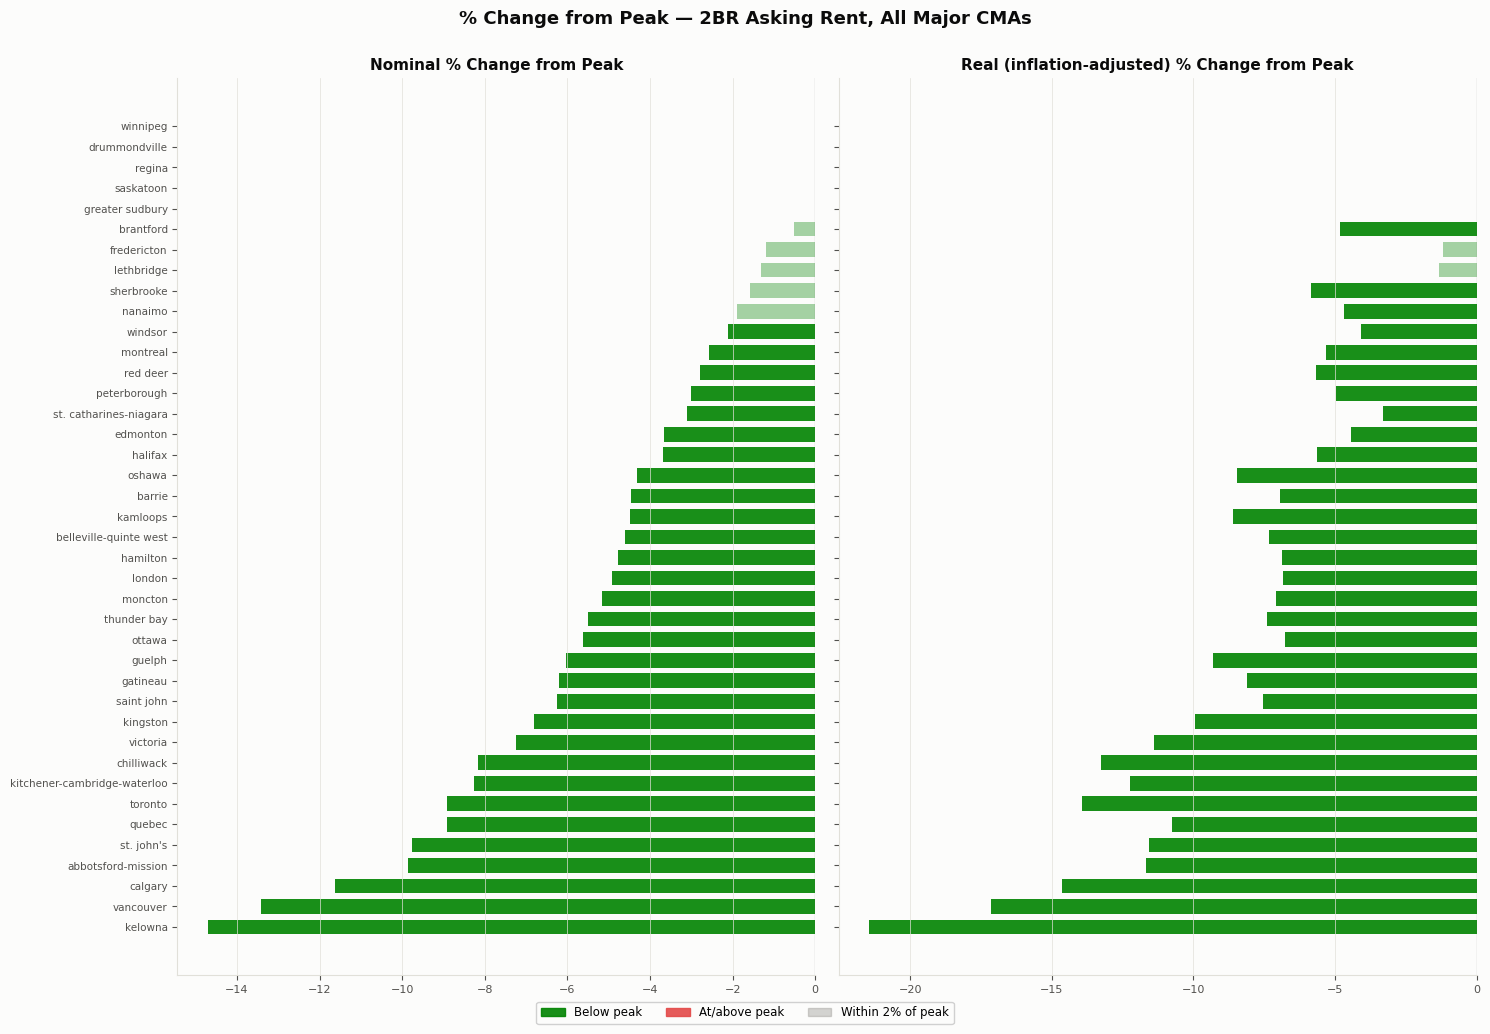

In [16]:
plot_df = asking_peak.sort_values('pct_nom')

fig, axes = plt.subplots(1, 2, figsize=(15, 10), sharey=True)

for ax, col, title in [
    (axes[0], 'pct_nom',  'Nominal'),
    (axes[1], 'pct_real', 'Real (inflation-adjusted)'),
]:
    vals = plot_df[col]
    colors = [C4 if v < 0 else C6 for v in vals]
    alphas = [0.90 if abs(v) >= abs(MATERIAL_DECLINE_PCT) else 0.35 for v in vals]
    for i, (v, c, a) in enumerate(zip(vals, colors, alphas)):
        ax.barh(i, v, color=c, alpha=a, edgecolor='none', height=0.72)
    ax.axvline(0, color=INK2, linewidth=0.8, zorder=3)
    ax.set_title(f'{title} % Change from Peak', fontsize=11, fontweight='bold', color=INK)
    ax.grid(axis='x')
    ax.tick_params(labelsize=8)

axes[0].set_yticks(range(len(plot_df)))
axes[0].set_yticklabels(plot_df.index, fontsize=7.5)

below_p  = mpatches.Patch(color=C4, alpha=0.9, label='Below peak')
above_p  = mpatches.Patch(color=C6, alpha=0.9, label='At/above peak')
faded_p  = mpatches.Patch(color=MUTED, alpha=0.35, label=f'Within {abs(MATERIAL_DECLINE_PCT):.0f}% of peak')
fig.legend(handles=[below_p, above_p, faded_p], loc='lower center', ncol=3,
           fontsize=8.5, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('% Change from Peak — 2BR Asking Rent, All Major CMAs', fontsize=13,
             fontweight='bold', color=INK, y=1.0)
plt.tight_layout()
plt.show()

## Section 9 — Every City: Nominal vs. Real, Peak to Latest

Every CMA with usable 2BR asking-rent data — ordered worst-correction-first
(same order as the Section 8 bars), so the story reads top-to-bottom,
left-to-right from biggest decline to smallest.

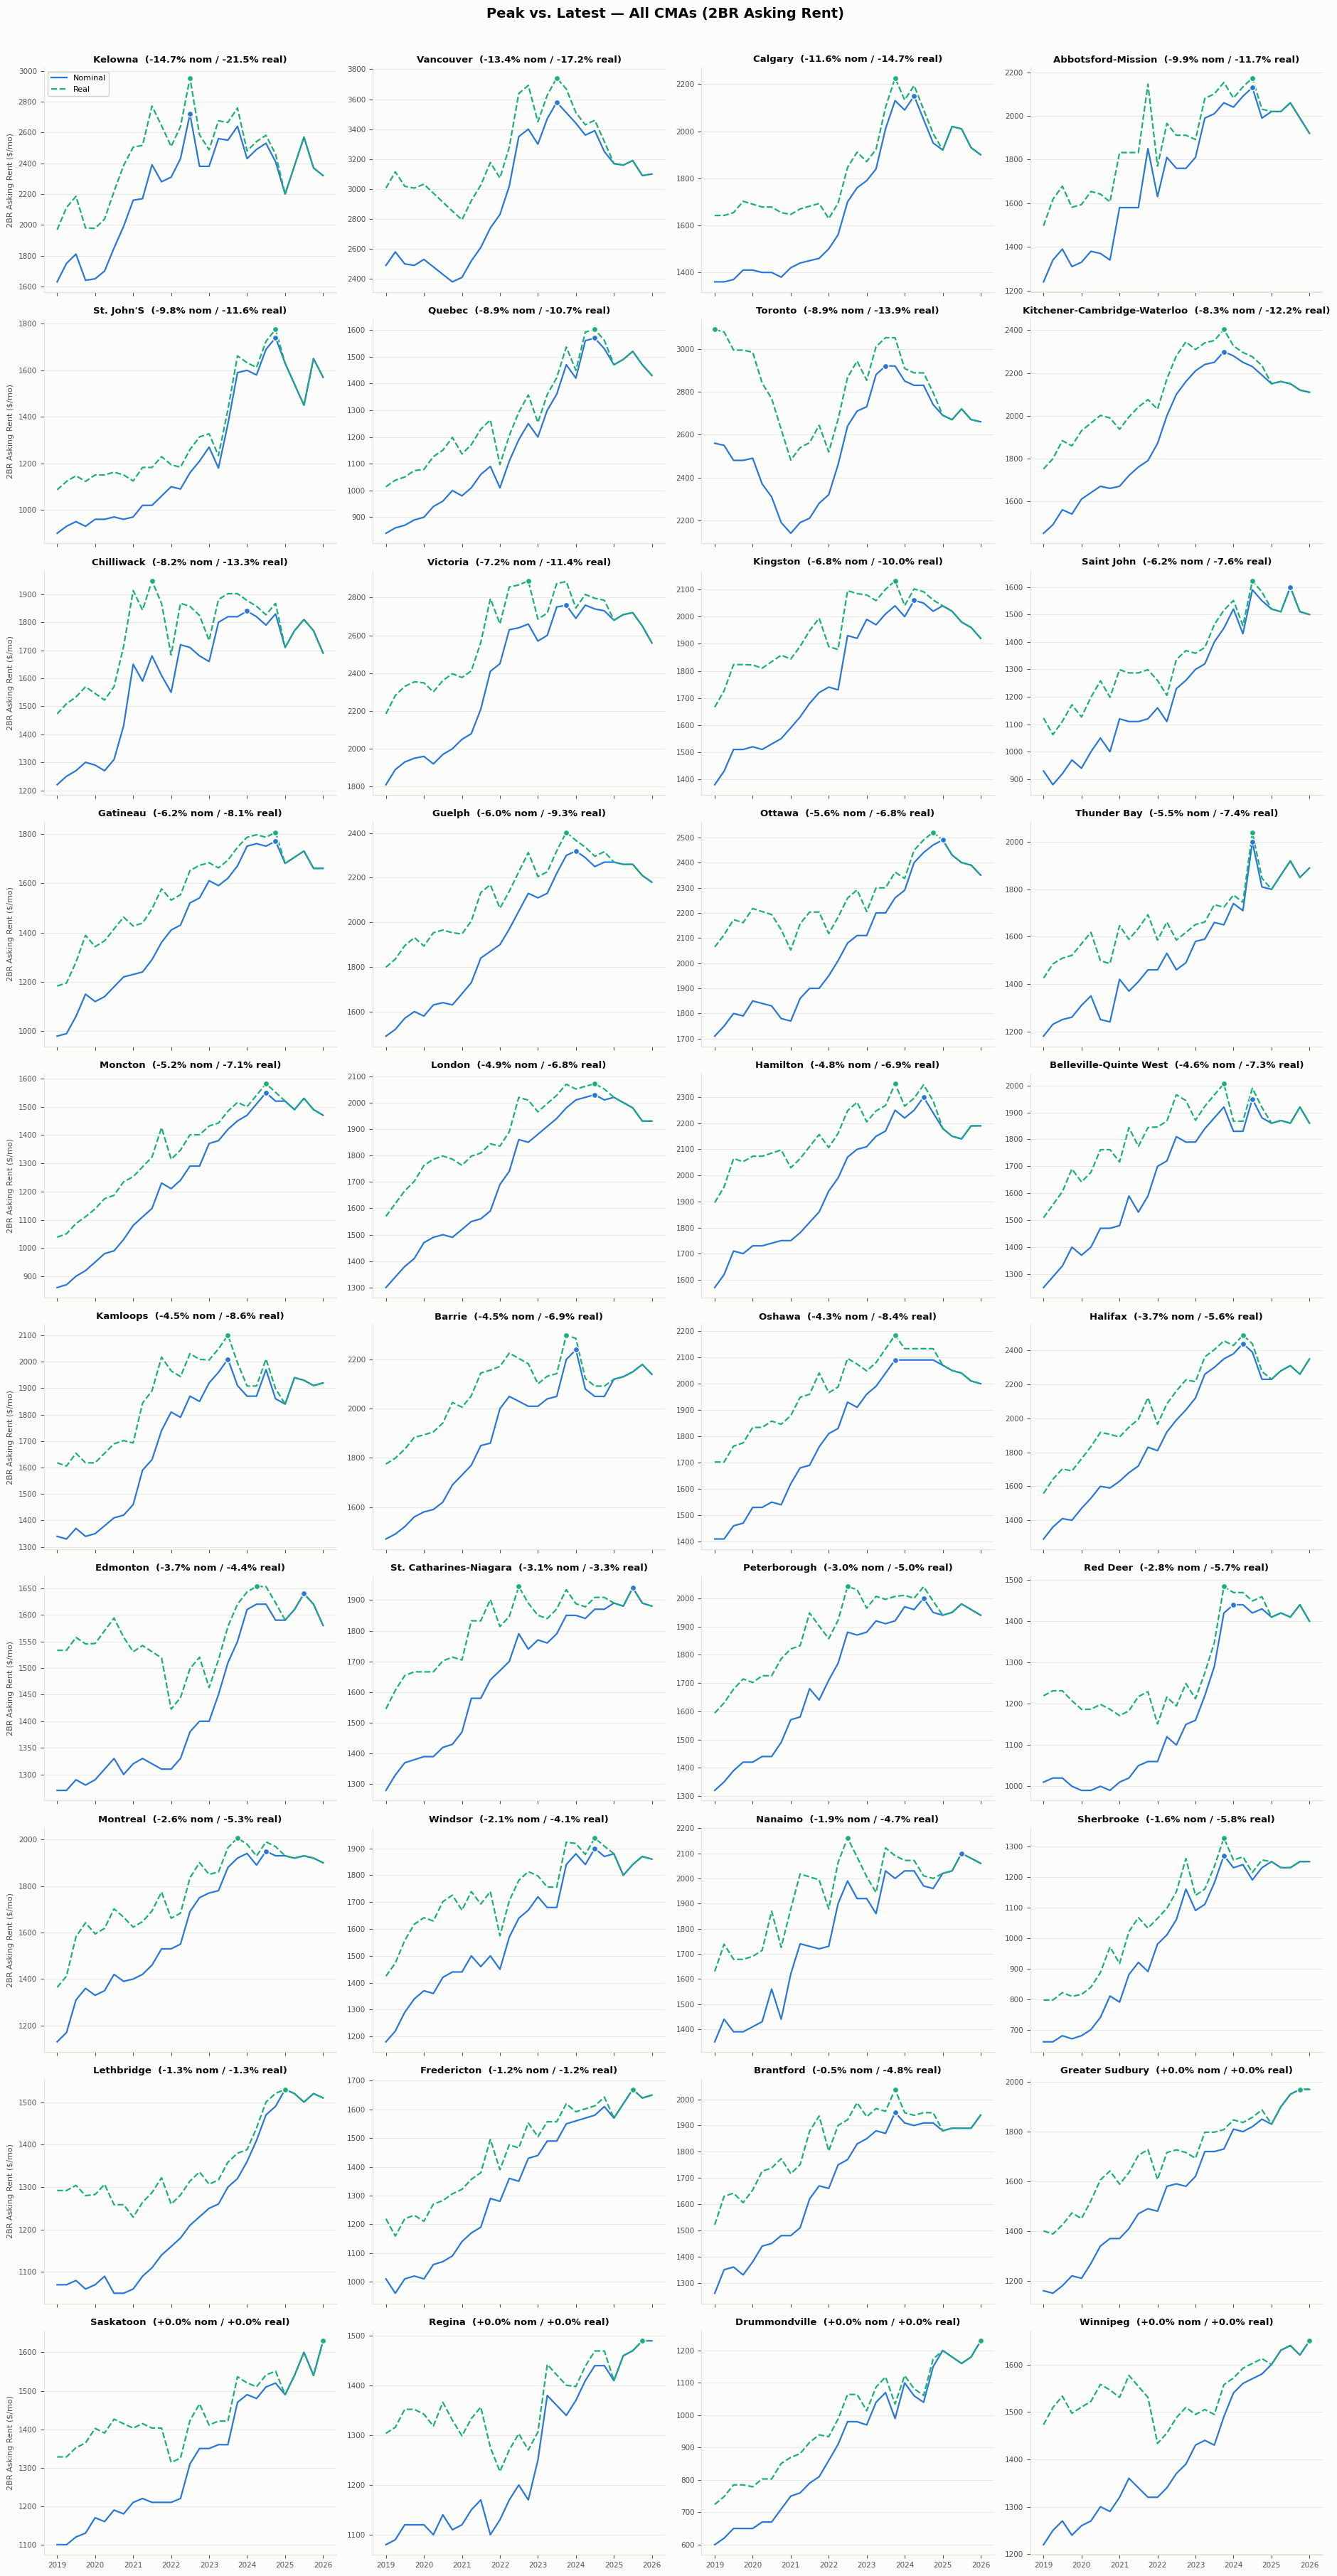

In [17]:
ASKING_CITY_ORDER = list(asking_peak.index)   # worst decline first, matches Section 8

N_COLS = 4
n_rows = -(-len(ASKING_CITY_ORDER) // N_COLS)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(4.7 * N_COLS, 3.6 * n_rows), sharex=True)

for ax, city in zip(axes.flat, ASKING_CITY_ORDER):
    series = asking[city]
    real = deflate_quarterly(series, CPI_CANADA)
    x = series.index.to_timestamp()

    ax.plot(x, series.values, color=C1, linewidth=1.6, label='Nominal')
    ax.plot(x, real.values, color=C2, linewidth=1.6, linestyle='--', label='Real')

    nom, rl = peak_stats(series), peak_stats(real)
    ax.scatter([nom['peak_period'].to_timestamp()], [nom['peak_value']],
               color=C1, s=35, zorder=6, edgecolors=SURFACE, linewidths=1.0)
    ax.scatter([rl['peak_period'].to_timestamp()], [rl['peak_value']],
               color=C2, s=35, zorder=6, edgecolors=SURFACE, linewidths=1.0)

    ax.set_title(f'{city.title()}  ({nom["pct_change"]:+.1f}% nom / {rl["pct_change"]:+.1f}% real)',
                 fontsize=9.5, fontweight='bold', color=INK)
    ax.grid(axis='y')
    ax.tick_params(labelsize=7.5)

for ax in axes.flat[len(ASKING_CITY_ORDER):]:
    ax.set_visible(False)

axes.flat[0].legend(loc='upper left', fontsize=8, framealpha=0.88)
for ax in axes[:, 0]:
    ax.set_ylabel('2BR Asking Rent ($/mo)', fontsize=8)

fig.suptitle('Peak vs. Latest — All CMAs (2BR Asking Rent)', fontsize=14,
             fontweight='bold', color=INK, y=1.005)
plt.tight_layout()
plt.show()

## Section 10 — How Rare Is a Multi-Year Decline, Historically?

CMHC's annual series lets us look back to 1990 (where available) for every
usable CMA. If declines like today's are unusual against 30+ years of
history, that supports "modest relative to what's come before"; if these
markets have seen bigger swings before, it cuts the other way. Panels are
ordered by number of down-years, most volatile first.

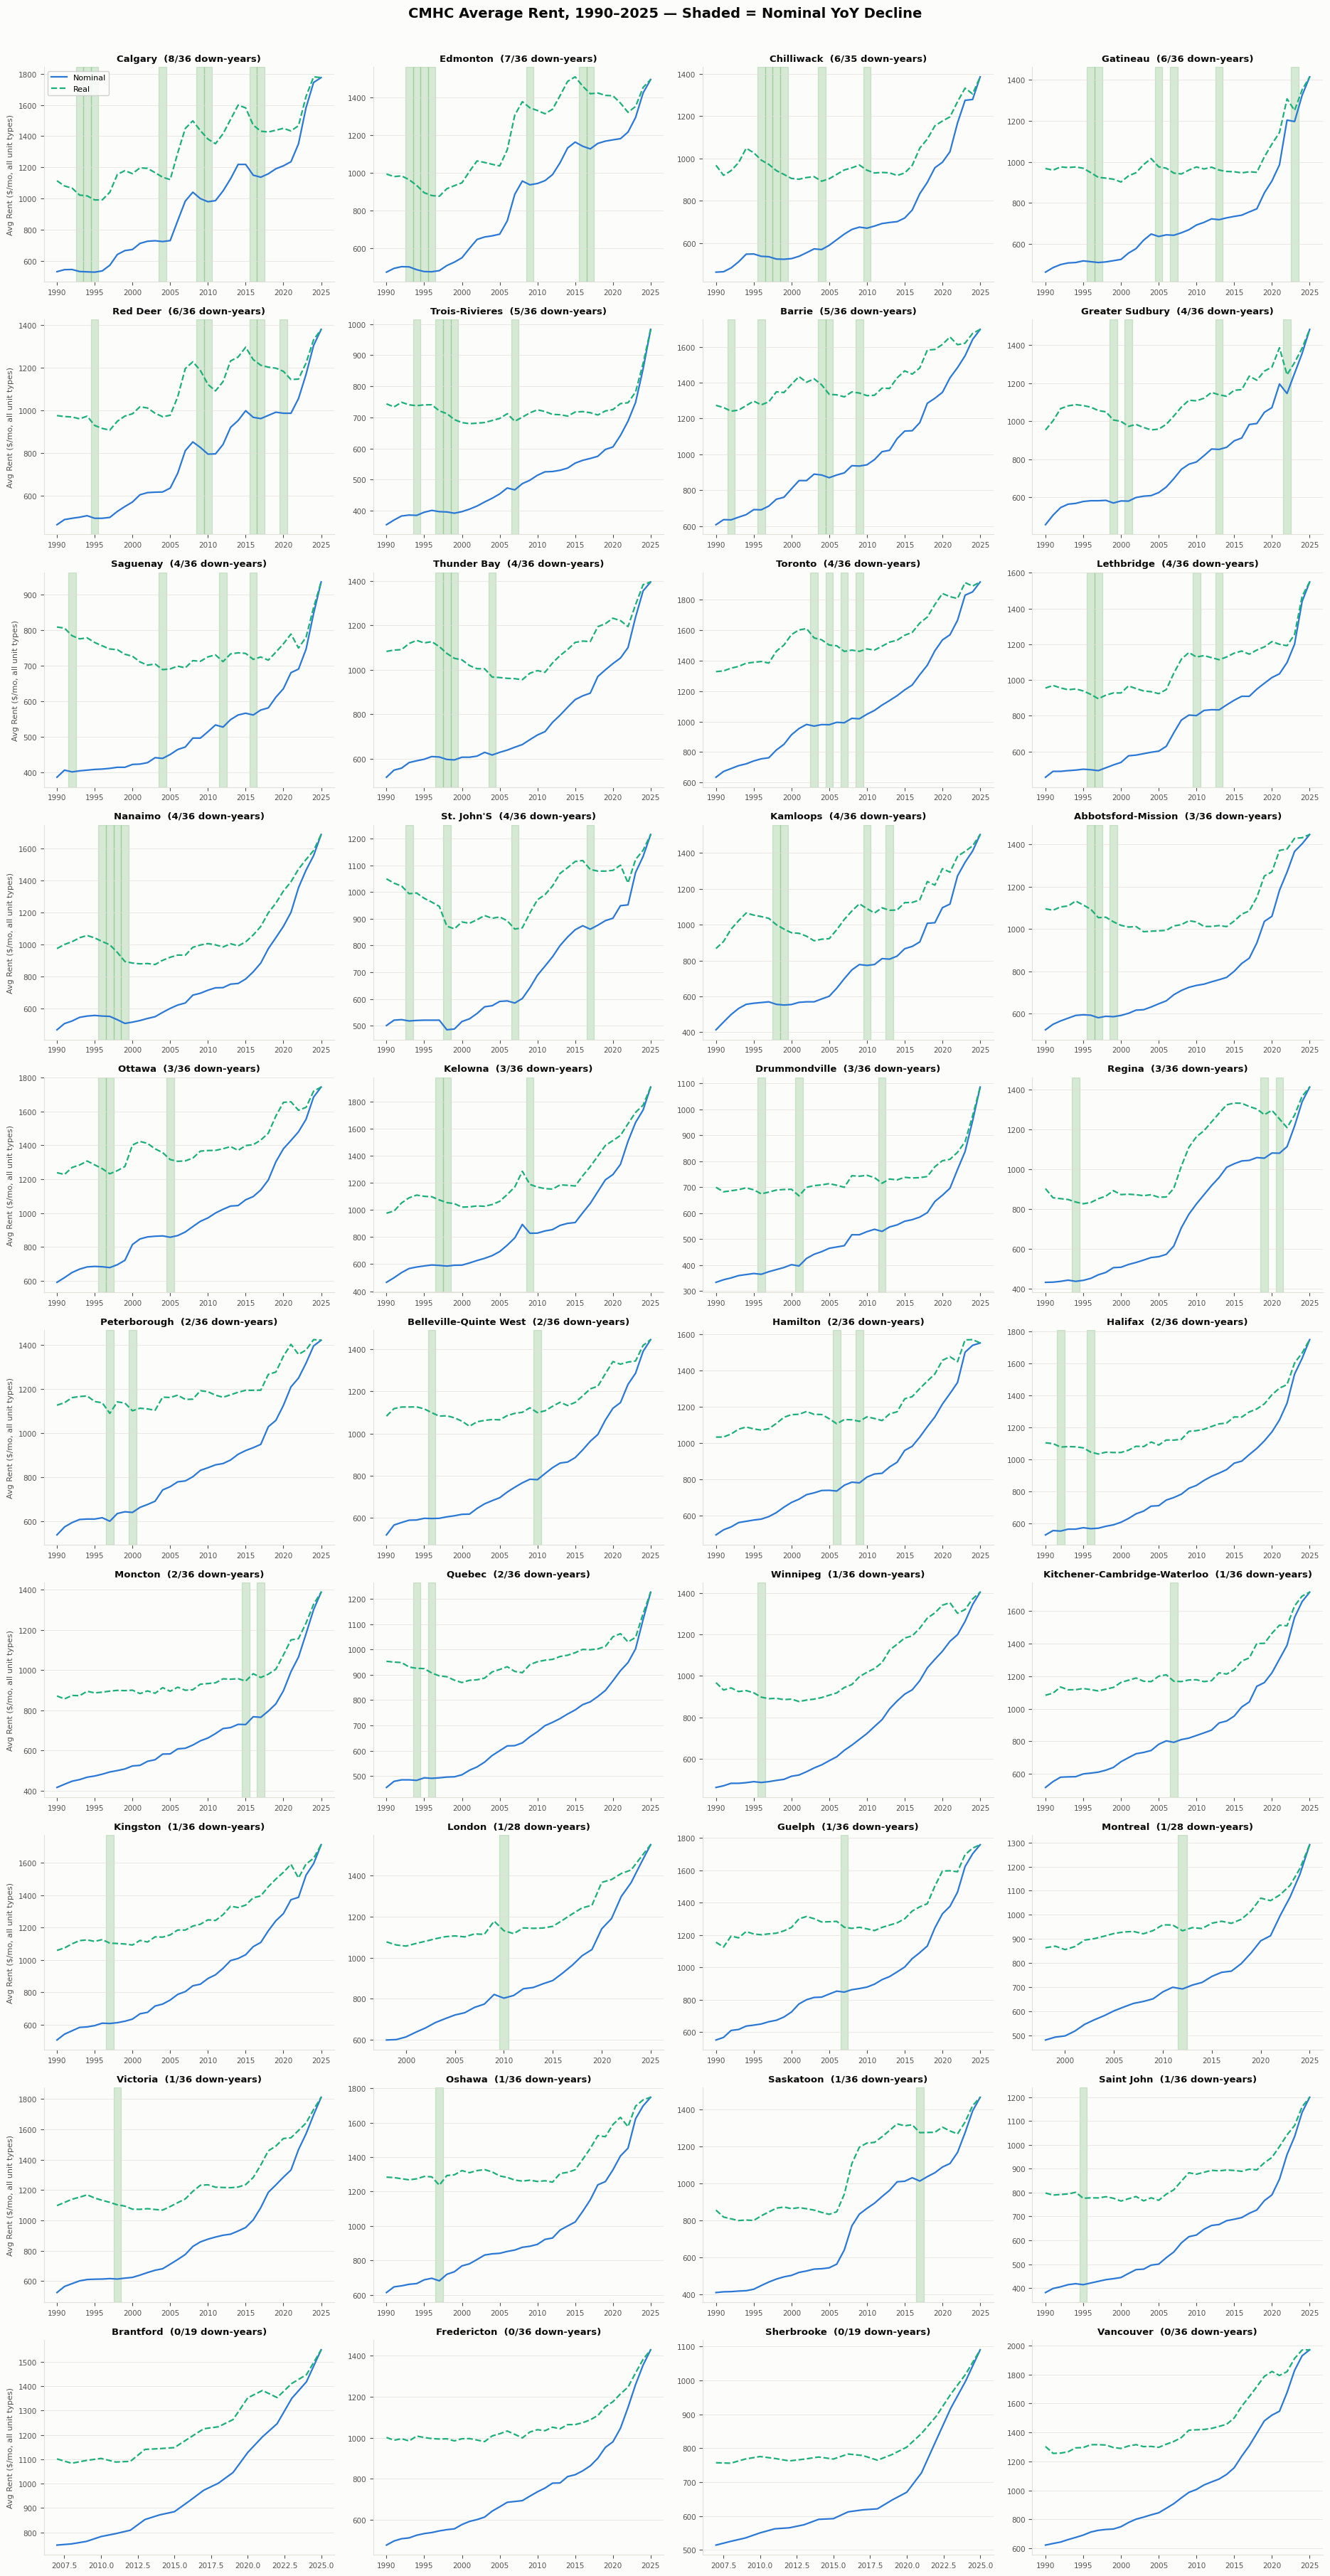

,n_years,n_down_years,pct_down_years,worst_down_year,worst_down_pct
city,,,,,
calgary,36,8,22.2,2016.0,-5.7
edmonton,36,7,19.4,1994.0,-3.0
chilliwack,35,6,17.1,1998.0,-2.1
gatineau,36,6,16.7,2005.0,-1.9
red deer,36,6,16.7,2010.0,-3.7
trois-rivieres,36,5,13.9,2007.0,-1.3
barrie,36,5,13.9,2005.0,-1.7
greater sudbury,36,4,11.1,2022.0,-4.2
saguenay,36,4,11.1,1992.0,-1.2


In [18]:
down_year_summary = []
for city, df in cmhc.items():
    series = df['Average Rent'].dropna()
    yoy_nom = series.pct_change() * 100
    down_years = yoy_nom[yoy_nom < 0]
    down_year_summary.append({
        'city': city, 'n_years': len(series), 'n_down_years': len(down_years),
        'pct_down_years': 100 * len(down_years) / len(series),
        'worst_down_year': down_years.idxmin() if len(down_years) else None,
        'worst_down_pct': down_years.min() if len(down_years) else 0.0,
    })
down_year_df = pd.DataFrame(down_year_summary).set_index('city')
CMHC_CITY_ORDER = down_year_df.sort_values('n_down_years', ascending=False).index.tolist()

N_COLS = 4
n_rows = -(-len(CMHC_CITY_ORDER) // N_COLS)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(4.7 * N_COLS, 3.6 * n_rows), sharex=False)

for ax, city in zip(axes.flat, CMHC_CITY_ORDER):
    series = cmhc[city]['Average Rent'].dropna()
    real = deflate_annual(series, CPI_CANADA)
    yoy_nom = series.pct_change() * 100

    ax.plot(series.index, series.values, color=C1, linewidth=1.6, label='Nominal')
    ax.plot(real.index, real.values, color=C2, linewidth=1.6, linestyle='--', label='Real')

    down_years = yoy_nom[yoy_nom < 0]
    for yr in down_years.index:
        ax.axvspan(yr - 0.5, yr + 0.5, color=C4, alpha=0.15, zorder=0)

    ax.set_title(f'{city.title()}  ({len(down_years)}/{len(series)} down-years)',
                 fontsize=9.5, fontweight='bold', color=INK)
    ax.grid(axis='y')
    ax.tick_params(labelsize=7.5)

for ax in axes.flat[len(CMHC_CITY_ORDER):]:
    ax.set_visible(False)

axes.flat[0].legend(loc='upper left', fontsize=8, framealpha=0.88)
for ax in axes[:, 0]:
    ax.set_ylabel('Avg Rent ($/mo, all unit types)', fontsize=8)

fig.suptitle('CMHC Average Rent, 1990–2025 — Shaded = Nominal YoY Decline', fontsize=14,
             fontweight='bold', color=INK, y=1.005)
plt.tight_layout()
plt.show()

down_year_df.loc[CMHC_CITY_ORDER].round(1)

In [19]:
# ── Is 2024/2025's dip unusual by historical standards? ───────────────────
all_yoy = []
for city, df in cmhc.items():
    yoy = df['Average Rent'].dropna().pct_change().dropna() * 100
    for yr, v in yoy.items():
        all_yoy.append({'city': city, 'year': yr, 'yoy_pct': v})
all_yoy = pd.DataFrame(all_yoy)

recent = all_yoy[all_yoy['year'] >= 2023]
historical = all_yoy[all_yoy['year'] < 2023]

print(f'CMHC year-over-year % change in average rent — all {all_yoy["city"].nunique()} usable CMAs')
print('-' * 68)
print(f'  Historical (pre-2023), n={len(historical)}: '
      f'mean {historical["yoy_pct"].mean():+.2f}%, '
      f'{int((historical["yoy_pct"] < 0).sum())} negative obs '
      f'({100*(historical["yoy_pct"] < 0).mean():.1f}%)')
print(f'  Recent (2023+), n={len(recent)}: '
      f'mean {recent["yoy_pct"].mean():+.2f}%, '
      f'{int((recent["yoy_pct"] < 0).sum())} negative obs '
      f'({100*(recent["yoy_pct"] < 0).mean():.1f}%)')
print()

u_stat, u_p = stats.mannwhitneyu(recent['yoy_pct'], historical['yoy_pct'], alternative='two-sided')
print('Mann-Whitney U (H0: recent and historical YoY changes are drawn from the same distribution):')
print(f'  U = {u_stat:.1f}  p = {u_p:.4f}')
print()
if recent['yoy_pct'].mean() > historical['yoy_pct'].mean():
    print('  Recent CMHC average-rent growth is significantly HIGHER than the historical')
    print('  norm, not lower. Whatever softening shows up in quarterly asking rents has')
    print('  not reached the annual average rent paid across the whole primary-market')
    print('  stock — if anything, CMHC records rents accelerating, likely because average')
    print('  rent blends in-place tenants (small regular increases) with turnover units')
    print('  now re-let at market rates, and lags the more current asking-rent series.')
else:
    print('  Recent CMHC average-rent growth is significantly lower than the historical')
    print('  norm, consistent with the asking-rent softening starting to show up in the')
    print('  broader, slower-moving average-rent measure too.')

CMHC year-over-year % change in average rent — all 40 usable CMAs
--------------------------------------------------------------------
  Historical (pre-2023), n=1229: mean +2.95%, 111 negative obs (9.0%)
  Recent (2023+), n=120: mean +7.61%, 1 negative obs (0.8%)

Mann-Whitney U (H0: recent and historical YoY changes are drawn from the same distribution):
  U = 126655.5  p = 0.0000

  Recent CMHC average-rent growth is significantly HIGHER than the historical
  norm, not lower. Whatever softening shows up in quarterly asking rents has
  not reached the annual average rent paid across the whole primary-market
  stock — if anything, CMHC records rents accelerating, likely because average
  rent blends in-place tenants (small regular increases) with turnover units
  now re-let at market rates, and lags the more current asking-rent series.


## Section 11 — Affordability: Rent Relative to Income

Median income data (Canada, 2024 constant dollars) runs 1990–2024, one year
short of the rent data. We pair national annual-average asking rent
(annualized, ×12) against median income for the overlapping years to see
whether affordability has meaningfully improved even where nominal rent has
dipped, or whether it's still near an all-time high.

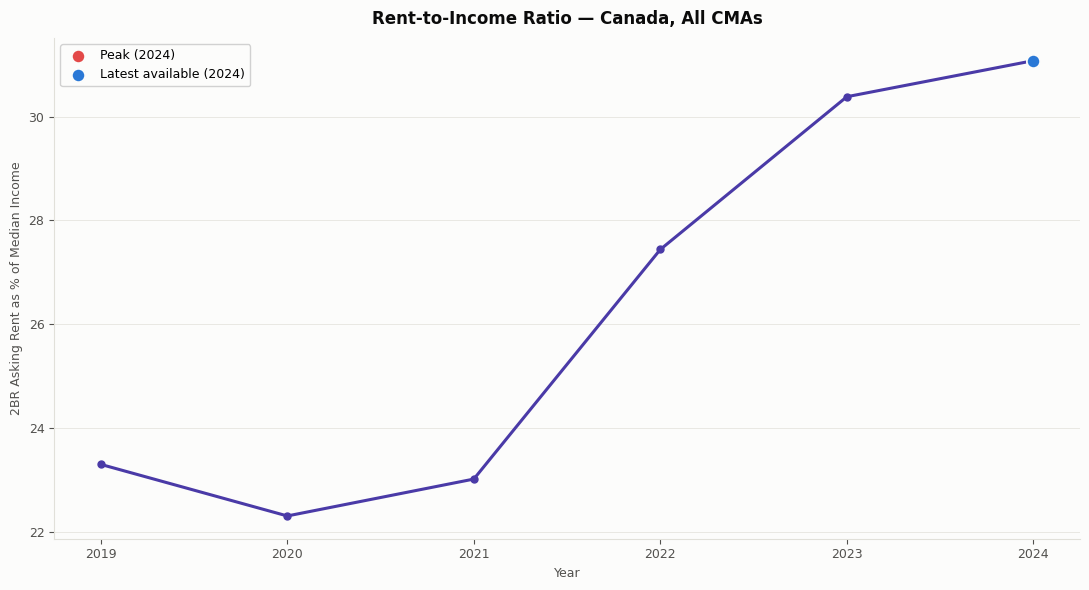

Peak rent-to-income ratio: 31.1% in 2024
Latest available ratio:    31.1% in 2024
Change: +0.0 percentage points

Note: income data ends 2024; rent data through Q1 2026 that
postdates 2024 is not reflected in this ratio.


In [20]:
asking_national_annual = asking_national.groupby(asking_national.index.year).mean()
overlap_years = sorted(set(asking_national_annual.index) & set(INCOME_CANADA.index))

afford = pd.DataFrame({
    'annual_rent': asking_national_annual.loc[overlap_years] * 12,
    'income':      INCOME_CANADA.loc[overlap_years],
})
afford['rent_pct_of_income'] = afford['annual_rent'] / afford['income'] * 100

peak_yr  = afford['rent_pct_of_income'].idxmax()
latest_yr = afford.index.max()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(afford.index, afford['rent_pct_of_income'], color=C5, linewidth=2.2, marker='o', markersize=5)
ax.scatter([peak_yr], [afford.loc[peak_yr, 'rent_pct_of_income']], color=C6, s=90, zorder=6,
           edgecolors=SURFACE, linewidths=1.2, label=f'Peak ({peak_yr})')
ax.scatter([latest_yr], [afford.loc[latest_yr, 'rent_pct_of_income']], color=C1, s=90, zorder=6,
           edgecolors=SURFACE, linewidths=1.2, label=f'Latest available ({latest_yr})')

ax.set_ylabel('2BR Asking Rent as % of Median Income', fontsize=9)
ax.set_xlabel('Year', fontsize=9)
ax.set_title('Rent-to-Income Ratio — Canada, All CMAs', fontsize=12, fontweight='bold',
             color=INK, pad=10)
ax.legend(loc='upper left', fontsize=9, framealpha=0.88)
ax.grid(axis='y')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

pct_from_peak = (afford.loc[latest_yr, 'rent_pct_of_income'] - afford.loc[peak_yr, 'rent_pct_of_income'])
print(f'Peak rent-to-income ratio: {afford.loc[peak_yr, "rent_pct_of_income"]:.1f}% in {peak_yr}')
print(f'Latest available ratio:    {afford.loc[latest_yr, "rent_pct_of_income"]:.1f}% in {latest_yr}')
print(f'Change: {pct_from_peak:+.1f} percentage points')
print()
print(f'Note: income data ends {INCOME_CANADA.index.max()}; rent data through Q1 2026 that')
print(f'postdates {INCOME_CANADA.index.max()} is not reflected in this ratio.')

## Section 12 — Conclusion

**The narrative has a real basis, but it's a leading-edge, partial, and so-far
modest correction — not a broad reversal.**

- **Nominal declines are real, widespread, and statistically significant, but
  small next to the run-up.** The national 2BR asking rent rose **+48%** from
  Q1 2019 to its Q4 2023 peak ($1,520 → $2,250), then fell **-4.4%** to Q1
  2026 — a correction equal to only about **9% of the preceding run-up**.
  Across 40 CMAs, 88% are below their own peak and 75% are down more than 2%
  (median **-4.6%**, mean **-4.9%**, both highly significant: t-test and
  Wilcoxon p < 0.0001) — so the softening shows up almost everywhere, but at a
  magnitude that barely dents the 2019–2023 gains.
- **Accounting for inflation, the correction is bigger than the sticker price
  suggests — not smaller.** Deflating to constant 2025 dollars, the average
  real decline from peak is **-7.3%** versus **-4.9%** nominal — a
  statistically significant gap (paired t-test/Wilcoxon, both p < 0.0001).
  CPI kept climbing after the peak, so a peak-era dollar was worth more than
  a latest-quarter dollar; re-stated in constant dollars, the peak itself was
  higher than its sticker price implies, which makes the drop since then
  larger once general inflation is stripped out. This says nothing about
  affordability against income (that's the next point) — only that rent has
  cooled by more than face value once compared like-for-like in constant
  dollars.
- **CMHC's slower, whole-market measure shows no decline anywhere at all.**
  Every one of the 40 usable CMAs recorded its all-time-high CMHC average rent
  (all unit types) in 2025, the latest year available — 0/40 have actually
  fallen from their own historical peak by this measure. Recent (2023+)
  year-over-year growth in CMHC average rent (**+7.6%/yr**) is significantly
  *higher* than the 1990–2022 historical norm (**+3.0%/yr**, Mann-Whitney
  p < 0.0001), not lower. Average rent blends in-place tenants (small
  scheduled increases) with turnover units re-let at market rates, and lags
  the more current asking-rent series — so the "falling rents" story is, so
  far, confined to the leading-edge asking-rent data and has not propagated
  into what the average tenant is actually paying.
- **Affordability hasn't improved in the years we can measure it.** Rent as a
  share of median income rose from 23.3% (2019) to 31.1% (2024) and is at its
  highest point in the overlap between the two data series — 2024 ties for
  the peak year, with no relief visible yet (income data doesn't yet extend
  into the 2025–2026 window where the asking-rent correction shows up).
- **The "recent" framing checks out, even if the size doesn't.** Peaks are
  not scattered evenly across 2019–2026 — 78% of CMAs peaked in 2024 or later,
  a highly significant clustering (chi-square p < 0.0001) rather than the
  even spread you'd expect from 40 cities drifting down independently. There
  really is a common, recent turning point behind the coverage; it's the
  *magnitude* of that turn, not its timing or its breadth, that the headlines
  overstate.

Taken together: where rents have fallen, it's a genuine, statistically
significant, widespread, and recently-synchronized cooling in *asking*
rents — but modest relative to what preceded it (single digits against a
run-up of tens of percent, confirmed both by a direct run-up-vs-correction
test and by a threshold test against a 10% "meaningful reversal" benchmark),
invisible so far in the broader average-rent and affordability data (a
paired McNemar test finds the two sources sharply disagree on which cities
are even below peak), and far from the "rents are coming down" reading the
headlines suggest.